# BD PowerCast — 24-Hour Electricity Demand Forecasting

## Recursive Multi-Step Forecasting with Custom Model B

The final one-hour forecasting model is the Adaptive Gated Ramp-Aware
Temporal Network.

Final one-hour test performance:

- MAE: 206.39 MW
- RMSE: 287.70 MW
- MAPE: 1.8297%
- R²: 0.9845

### Objective

Extend the trained one-hour model to generate a rolling 24-hour demand
forecast.

The forecast is generated recursively:

1. Predict hour t+1.
2. Insert the prediction into the temporary demand history.
3. Recalculate the required lag, rolling, and ramp features.
4. Predict t+2.
5. Continue until t+24.

The trained model parameters are not modified in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import joblib
import json
import os

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA GeForce RTX 5050


In [2]:
df = pd.read_csv(
    "../data/processed/PGCB_hourly_preprocessed_stage6_continuous.csv",
    parse_dates=["datetime"]
)

df = df.sort_values(
    "datetime"
).reset_index(drop=True)

print("Dataset shape:", df.shape)

print(
    "Date range:",
    df["datetime"].min(),
    "→",
    df["datetime"].max()
)

Dataset shape: (89101, 61)
Date range: 2015-04-19 00:00:00 → 2025-06-17 12:00:00


In [3]:
df = pd.read_csv(
    "../data/processed/PGCB_hourly_preprocessed_stage6_continuous.csv",
    parse_dates=["datetime"]
)

df = df.sort_values(
    "datetime"
).reset_index(drop=True)

print("Dataset shape:", df.shape)

print(
    "Date range:",
    df["datetime"].min(),
    "→",
    df["datetime"].max()
)

Dataset shape: (89101, 61)
Date range: 2015-04-19 00:00:00 → 2025-06-17 12:00:00


In [4]:
with open(
    "../models/model_b_feature_config.json",
    "r"
) as f:
    feature_config = json.load(f)

recent_features = (
    feature_config["recent_features"]
)

daily_features = (
    feature_config["daily_features"]
)

weekly_features = (
    feature_config["weekly_features"]
)

calendar_features = (
    feature_config["calendar_features"]
)

ramp_features = (
    feature_config["ramp_features"]
)

target = feature_config["target"]

print("Recent:", recent_features)
print("Daily:", daily_features)
print("Weekly:", weekly_features)
print("Calendar:", calendar_features)
print("Ramp:", ramp_features)
print("Target:", target)

Recent: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_24']
Daily: ['lag_24', 'lag_48', 'lag_72', 'rolling_mean_24', 'rolling_max_24', 'rolling_min_24']
Weekly: ['lag_168', 'lag_336', 'lag_504', 'lag_672', 'rolling_mean_168']
Calendar: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_friday']
Ramp: ['change_1', 'change_2', 'change_3', 'recent_vs_daily', 'recent_vs_weekly', 'range_6', 'rolling_std_6']
Target: demand_mw_clean


In [5]:
with open(
    "../models/model_b_feature_config.json",
    "r"
) as f:
    feature_config = json.load(f)

recent_features = (
    feature_config["recent_features"]
)

daily_features = (
    feature_config["daily_features"]
)

weekly_features = (
    feature_config["weekly_features"]
)

calendar_features = (
    feature_config["calendar_features"]
)

ramp_features = (
    feature_config["ramp_features"]
)

target = feature_config["target"]

print("Recent:", recent_features)
print("Daily:", daily_features)
print("Weekly:", weekly_features)
print("Calendar:", calendar_features)
print("Ramp:", ramp_features)
print("Target:", target)

Recent: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_24']
Daily: ['lag_24', 'lag_48', 'lag_72', 'rolling_mean_24', 'rolling_max_24', 'rolling_min_24']
Weekly: ['lag_168', 'lag_336', 'lag_504', 'lag_672', 'rolling_mean_168']
Calendar: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_friday']
Ramp: ['change_1', 'change_2', 'change_3', 'recent_vs_daily', 'recent_vs_weekly', 'range_6', 'rolling_std_6']
Target: demand_mw_clean


In [6]:
required_files = [
    "../models/custom_model_b.pth",
    "../models/recent_scaler.pkl",
    "../models/daily_scaler.pkl",
    "../models/weekly_scaler.pkl",
    "../models/calendar_scaler.pkl",
    "../models/ramp_scaler.pkl",
    "../models/target_scaler.pkl",
    "../models/model_b_feature_config.json"
]

for path in required_files:
    print(
        "OK" if os.path.exists(path) else "MISSING",
        path
    )

OK ../models/custom_model_b.pth
OK ../models/recent_scaler.pkl
OK ../models/daily_scaler.pkl
OK ../models/weekly_scaler.pkl
OK ../models/calendar_scaler.pkl
OK ../models/ramp_scaler.pkl
OK ../models/target_scaler.pkl
OK ../models/model_b_feature_config.json


redefine Model B

In [7]:
class AdaptiveGatedDemandNet(nn.Module):

    def __init__(
        self,
        recent_dim,
        daily_dim,
        weekly_dim,
        calendar_dim,
        ramp_dim
    ):
        super().__init__()

        self.recent_branch = nn.Sequential(
            nn.Linear(recent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.daily_branch = nn.Sequential(
            nn.Linear(daily_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.weekly_branch = nn.Sequential(
            nn.Linear(weekly_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.ramp_branch = nn.Sequential(
            nn.Linear(ramp_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.calendar_branch = nn.Sequential(
            nn.Linear(calendar_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        self.gate = nn.Sequential(
            nn.Linear(24, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

        self.fusion = nn.Sequential(
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(48, 24),
            nn.ReLU(),

            nn.Linear(24, 1)
        )

    def forward(
        self,
        recent,
        daily,
        weekly,
        calendar,
        ramp
    ):

        recent_out = self.recent_branch(recent)
        daily_out = self.daily_branch(daily)
        weekly_out = self.weekly_branch(weekly)
        ramp_out = self.ramp_branch(ramp)

        calendar_out = self.calendar_branch(
            calendar
        )

        gate_context = torch.cat(
            [calendar_out, ramp_out],
            dim=1
        )

        gate_weights = torch.softmax(
            self.gate(gate_context),
            dim=1
        )

        branch_outputs = torch.stack(
            [
                recent_out,
                daily_out,
                weekly_out,
                ramp_out
            ],
            dim=1
        )

        weighted_temporal = (
            branch_outputs
            * gate_weights.unsqueeze(-1)
        ).sum(dim=1)

        combined = torch.cat(
            [
                weighted_temporal,
                calendar_out
            ],
            dim=1
        )

        prediction = self.fusion(
            combined
        )

        return (
            prediction.squeeze(1),
            gate_weights
        )

load the trained model

In [8]:
model_b = AdaptiveGatedDemandNet(
    recent_dim=len(recent_features),
    daily_dim=len(daily_features),
    weekly_dim=len(weekly_features),
    calendar_dim=len(calendar_features),
    ramp_dim=len(ramp_features)
).to(device)

model_b.load_state_dict(
    torch.load(
        "../models/custom_model_b.pth",
        map_location=device
    )
)

model_b.eval()

print("Custom Model B loaded.")

Custom Model B loaded.


helper to create features for one forecast hour

In [9]:
def build_features_for_time(
    history,
    forecast_time
):

    history = history.sort_index()

    def lag(hours):
        return history.loc[
            forecast_time - pd.Timedelta(hours=hours)
        ]

    past_values = history[
        history.index < forecast_time
    ]

    recent_3 = past_values.tail(3)
    recent_6 = past_values.tail(6)
    recent_24 = past_values.tail(24)
    recent_168 = past_values.tail(168)

    hour = forecast_time.hour
    dow = forecast_time.dayofweek
    month = forecast_time.month

    features = {}

    # Recent
    features["lag_1"] = lag(1)
    features["lag_2"] = lag(2)
    features["lag_3"] = lag(3)

    features["rolling_mean_3"] = (
        recent_3.mean()
    )

    features["rolling_mean_6"] = (
        recent_6.mean()
    )

    features["rolling_std_24"] = (
        recent_24.std()
    )

    # Daily
    features["lag_24"] = lag(24)
    features["lag_48"] = lag(48)
    features["lag_72"] = lag(72)

    features["rolling_mean_24"] = (
        recent_24.mean()
    )

    features["rolling_max_24"] = (
        recent_24.max()
    )

    features["rolling_min_24"] = (
        recent_24.min()
    )

    # Weekly
    features["lag_168"] = lag(168)
    features["lag_336"] = lag(336)
    features["lag_504"] = lag(504)
    features["lag_672"] = lag(672)

    features["rolling_mean_168"] = (
        recent_168.mean()
    )

    # Calendar
    features["hour_sin"] = np.sin(
        2 * np.pi * hour / 24
    )

    features["hour_cos"] = np.cos(
        2 * np.pi * hour / 24
    )

    features["dow_sin"] = np.sin(
        2 * np.pi * dow / 7
    )

    features["dow_cos"] = np.cos(
        2 * np.pi * dow / 7
    )

    features["month_sin"] = np.sin(
        2 * np.pi * (month - 1) / 12
    )

    features["month_cos"] = np.cos(
        2 * np.pi * (month - 1) / 12
    )

    features["is_friday"] = int(
        dow == 4
    )

    # Ramp
    features["change_1"] = (
        lag(1) - lag(2)
    )

    features["change_2"] = (
        lag(2) - lag(3)
    )

    features["change_3"] = (
        lag(3) - lag(4)
    )

    features["recent_vs_daily"] = (
        lag(1) - lag(24)
    )

    features["recent_vs_weekly"] = (
        lag(1) - lag(168)
    )

    features["range_6"] = (
        recent_6.max()
        - recent_6.min()
    )

    features["rolling_std_6"] = (
        recent_6.std()
    )

    return features

quick sanity check

In [10]:
history = (
    df.set_index("datetime")[
        "demand_mw_clean"
    ].copy()
)

sample_time = pd.Timestamp(
    "2024-01-02 00:00:00"
)

sample_features = build_features_for_time(
    history,
    sample_time
)

print(
    "Number of features:",
    len(sample_features)
)

sample_features

Number of features: 31


{'lag_1': np.float64(7923.0),
 'lag_2': np.float64(8312.0),
 'lag_3': np.float64(8860.0),
 'rolling_mean_3': np.float64(8365.0),
 'rolling_mean_6': np.float64(9037.5),
 'rolling_std_24': np.float64(984.6200243704697),
 'lag_24': np.float64(7580.0),
 'lag_48': np.float64(7601.0),
 'lag_72': np.float64(7141.0),
 'rolling_mean_24': np.float64(8331.375),
 'rolling_max_24': np.float64(9944.0),
 'rolling_min_24': np.float64(6598.0),
 'lag_168': np.float64(7444.0),
 'lag_336': np.float64(7267.0),
 'lag_504': np.float64(7496.0),
 'lag_672': np.float64(8345.0),
 'rolling_mean_168': np.float64(8382.305389221558),
 'hour_sin': np.float64(0.0),
 'hour_cos': np.float64(1.0),
 'dow_sin': np.float64(0.7818314824680298),
 'dow_cos': np.float64(0.6234898018587336),
 'month_sin': np.float64(0.0),
 'month_cos': np.float64(1.0),
 'is_friday': 0,
 'change_1': np.float64(-389.0),
 'change_2': np.float64(-548.0),
 'change_3': np.float64(-563.0),
 'recent_vs_daily': np.float64(343.0),
 'recent_vs_weekly': np.

predict one hour from a feature dictionary

In [11]:
def predict_one_hour(features):

    # Arrange features in the exact training order
    recent_df = pd.DataFrame(
        [[features[f] for f in recent_features]],
        columns=recent_features
    )

    daily_df = pd.DataFrame(
        [[features[f] for f in daily_features]],
        columns=daily_features
    )

    weekly_df = pd.DataFrame(
        [[features[f] for f in weekly_features]],
        columns=weekly_features
    )

    calendar_df = pd.DataFrame(
        [[features[f] for f in calendar_features]],
        columns=calendar_features
    )

    ramp_df = pd.DataFrame(
        [[features[f] for f in ramp_features]],
        columns=ramp_features
    )

    # Scale with the original training-only scalers
    recent_scaled = recent_scaler.transform(recent_df)
    daily_scaled = daily_scaler.transform(daily_df)
    weekly_scaled = weekly_scaler.transform(weekly_df)
    calendar_scaled = calendar_scaler.transform(calendar_df)
    ramp_scaled = ramp_scaler.transform(ramp_df)

    # Convert to tensors
    recent_tensor = torch.tensor(
        recent_scaled,
        dtype=torch.float32,
        device=device
    )

    daily_tensor = torch.tensor(
        daily_scaled,
        dtype=torch.float32,
        device=device
    )

    weekly_tensor = torch.tensor(
        weekly_scaled,
        dtype=torch.float32,
        device=device
    )

    calendar_tensor = torch.tensor(
        calendar_scaled,
        dtype=torch.float32,
        device=device
    )

    ramp_tensor = torch.tensor(
        ramp_scaled,
        dtype=torch.float32,
        device=device
    )

    model_b.eval()

    with torch.no_grad():

        prediction_scaled, gate_weights = model_b(
            recent_tensor,
            daily_tensor,
            weekly_tensor,
            calendar_tensor,
            ramp_tensor
        )

    # Convert scaled prediction back to MW
    prediction_mw = target_scaler.inverse_transform(
        prediction_scaled
        .cpu()
        .numpy()
        .reshape(-1, 1)
    )[0, 0]

    gate_weights = (
        gate_weights
        .cpu()
        .numpy()[0]
    )

    return prediction_mw, gate_weights

recursive 24-hour forecasting function

In [15]:
def forecast_24_hours(
    full_history,
    forecast_start,
    horizon=24
):

    forecast_start = pd.Timestamp(
        forecast_start
    )

    # IMPORTANT:
    # Remove all demand values at and after forecast_start.
    # This prevents future actual demand leakage.
    history = full_history[
        full_history.index < forecast_start
    ].copy()

    forecasts = []

    for step in range(horizon):

        forecast_time = (
            forecast_start
            + pd.Timedelta(hours=step)
        )

        # Build Model B features using only
        # historical observations + earlier predictions
        features = build_features_for_time(
            history,
            forecast_time
        )

        # Check for unexpected missing features
        missing_features = [
            name
            for name, value in features.items()
            if pd.isna(value)
        ]

        if missing_features:
            raise ValueError(
                f"Missing features at {forecast_time}: "
                f"{missing_features}"
            )

        prediction_mw, weights = (
            predict_one_hour(features)
        )

        forecasts.append({
            "datetime": forecast_time,
            "forecast_hour": step + 1,
            "predicted_demand_mw": prediction_mw,
            "recent_weight": weights[0],
            "daily_weight": weights[1],
            "weekly_weight": weights[2],
            "ramp_weight": weights[3]
        })

        # Recursive step:
        # prediction becomes part of history
        history.loc[forecast_time] = (
            prediction_mw
        )

    return pd.DataFrame(forecasts)

test it on a historical date

In [18]:
import joblib

recent_scaler = joblib.load(
    "../models/recent_scaler.pkl"
)

daily_scaler = joblib.load(
    "../models/daily_scaler.pkl"
)

weekly_scaler = joblib.load(
    "../models/weekly_scaler.pkl"
)

calendar_scaler = joblib.load(
    "../models/calendar_scaler.pkl"
)

ramp_scaler = joblib.load(
    "../models/ramp_scaler.pkl"
)

target_scaler = joblib.load(
    "../models/target_scaler.pkl"
)

print("All scalers loaded successfully.")

All scalers loaded successfully.


In [19]:
forecast_start = pd.Timestamp(
    "2024-03-01 00:00:00"
)

full_history = (
    df.set_index("datetime")[
        "demand_mw_clean"
    ].copy()
)

forecast_24 = forecast_24_hours(
    full_history=full_history,
    forecast_start=forecast_start,
    horizon=24
)

forecast_24

,datetime,forecast_hour,predicted_demand_mw,recent_weight,daily_weight,weekly_weight,ramp_weight
0,2024-03-01 00:00:00,1,9032.059570,0.621425,0.173457,0.051876,0.153243
1,2024-03-01 01:00:00,2,8745.518555,0.608481,0.182571,0.059210,0.149738
2,2024-03-01 02:00:00,3,8487.327148,0.590290,0.191543,0.070925,0.147242
3,2024-03-01 03:00:00,4,8227.465820,0.563614,0.200111,0.090684,0.145590
4,2024-03-01 04:00:00,5,7976.200195,0.512890,0.229226,0.113607,0.144276
5,2024-03-01 05:00:00,6,7868.312012,0.449406,0.276569,0.147770,0.126255
6,2024-03-01 06:00:00,7,7818.118164,0.438084,0.270862,0.164998,0.126055
7,2024-03-01 07:00:00,8,7893.472656,0.552299,0.201562,0.118458,0.127681
8,2024-03-01 08:00:00,9,8164.983398,0.546661,0.210698,0.114004,0.128637
9,2024-03-01 09:00:00,10,8683.900391,0.484266,0.254629,0.127569,0.133536


In [20]:
forecast_start = pd.Timestamp(
    "2024-03-01 00:00:00"
)

full_history = (
    df.set_index("datetime")[
        "demand_mw_clean"
    ].copy()
)

forecast_24 = forecast_24_hours(
    full_history=full_history,
    forecast_start=forecast_start,
    horizon=24
)

forecast_24

,datetime,forecast_hour,predicted_demand_mw,recent_weight,daily_weight,weekly_weight,ramp_weight
0,2024-03-01 00:00:00,1,9032.059570,0.621425,0.173457,0.051876,0.153243
1,2024-03-01 01:00:00,2,8745.518555,0.608481,0.182571,0.059210,0.149738
2,2024-03-01 02:00:00,3,8487.327148,0.590290,0.191543,0.070925,0.147242
3,2024-03-01 03:00:00,4,8227.465820,0.563614,0.200111,0.090684,0.145590
4,2024-03-01 04:00:00,5,7976.200195,0.512890,0.229226,0.113607,0.144276
5,2024-03-01 05:00:00,6,7868.312012,0.449406,0.276569,0.147770,0.126255
6,2024-03-01 06:00:00,7,7818.118164,0.438084,0.270862,0.164998,0.126055
7,2024-03-01 07:00:00,8,7893.472656,0.552299,0.201562,0.118458,0.127681
8,2024-03-01 08:00:00,9,8164.983398,0.546661,0.210698,0.114004,0.128637
9,2024-03-01 09:00:00,10,8683.900391,0.484266,0.254629,0.127569,0.133536


In [21]:
actual_24 = (
    df.set_index("datetime")
    .loc[
        forecast_24["datetime"],
        "demand_mw_clean"
    ]
    .to_numpy()
)

forecast_24["actual_demand_mw"] = (
    actual_24
)

forecast_24[
    [
        "datetime",
        "forecast_hour",
        "actual_demand_mw",
        "predicted_demand_mw"
    ]
]

,datetime,forecast_hour,actual_demand_mw,predicted_demand_mw
0,2024-03-01 00:00:00,1,8914.0,9032.059570
1,2024-03-01 01:00:00,2,8482.0,8745.518555
2,2024-03-01 02:00:00,3,8219.0,8487.327148
3,2024-03-01 03:00:00,4,8030.0,8227.465820
4,2024-03-01 04:00:00,5,7900.0,7976.200195
5,2024-03-01 05:00:00,6,8091.0,7868.312012
6,2024-03-01 06:00:00,7,8463.0,7818.118164
7,2024-03-01 07:00:00,8,9090.0,7893.472656
8,2024-03-01 08:00:00,9,9193.0,8164.983398
9,2024-03-01 09:00:00,10,9154.0,8683.900391


In [22]:
y_actual_24 = (
    forecast_24["actual_demand_mw"]
    .to_numpy()
)

y_pred_24 = (
    forecast_24["predicted_demand_mw"]
    .to_numpy()
)

mae_24 = mean_absolute_error(
    y_actual_24,
    y_pred_24
)

rmse_24 = np.sqrt(
    mean_squared_error(
        y_actual_24,
        y_pred_24
    )
)

mape_24 = (
    np.mean(
        np.abs(
            (
                y_actual_24
                - y_pred_24
            )
            / y_actual_24
        )
    )
    * 100
)

r2_24 = r2_score(
    y_actual_24,
    y_pred_24
)

print("24-HOUR RECURSIVE FORECAST")
print("=" * 35)

print(f"MAE  : {mae_24:.2f} MW")
print(f"RMSE : {rmse_24:.2f} MW")
print(f"MAPE : {mape_24:.4f}%")
print(f"R²   : {r2_24:.4f}")

24-HOUR RECURSIVE FORECAST
MAE  : 625.88 MW
RMSE : 735.75 MW
MAPE : 6.8327%
R²   : -0.2734


## Direct 24-Hour Forecasting

The recursive one-hour rollout produced substantial error accumulation.

Therefore, a direct multi-horizon architecture is evaluated.

For each forecast origin, the model predicts:

t, t+1, t+2, ..., t+23

simultaneously.

Model development uses the 2023 validation period only.
The 2024+ test period remains reserved for final evaluation.

In [23]:
# Recent lags
df["lag_1"] = df["demand_mw_clean"].shift(1)
df["lag_2"] = df["demand_mw_clean"].shift(2)
df["lag_3"] = df["demand_mw_clean"].shift(3)

# Daily
df["lag_24"] = df["demand_mw_clean"].shift(24)
df["lag_48"] = df["demand_mw_clean"].shift(48)
df["lag_72"] = df["demand_mw_clean"].shift(72)

# Weekly
df["lag_168"] = df["demand_mw_clean"].shift(168)
df["lag_336"] = df["demand_mw_clean"].shift(336)
df["lag_504"] = df["demand_mw_clean"].shift(504)
df["lag_672"] = df["demand_mw_clean"].shift(672)

past_demand = df["demand_mw_clean"].shift(1)

df["rolling_mean_3"] = past_demand.rolling(3).mean()
df["rolling_mean_6"] = past_demand.rolling(6).mean()

df["rolling_mean_24"] = past_demand.rolling(24).mean()
df["rolling_std_24"] = past_demand.rolling(24).std()
df["rolling_max_24"] = past_demand.rolling(24).max()
df["rolling_min_24"] = past_demand.rolling(24).min()

df["rolling_mean_168"] = past_demand.rolling(168).mean()

# Calendar
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(
    2 * np.pi * (df["month"] - 1) / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * (df["month"] - 1) / 12
)

df["is_friday"] = (
    df["day_of_week"] == 4
).astype(int)

# Ramp
df["change_1"] = (
    df["demand_mw_clean"].shift(1)
    - df["demand_mw_clean"].shift(2)
)

df["change_2"] = (
    df["demand_mw_clean"].shift(2)
    - df["demand_mw_clean"].shift(3)
)

df["change_3"] = (
    df["demand_mw_clean"].shift(3)
    - df["demand_mw_clean"].shift(4)
)

df["recent_vs_daily"] = (
    df["lag_1"] - df["lag_24"]
)

df["recent_vs_weekly"] = (
    df["lag_1"] - df["lag_168"]
)

df["rolling_max_6"] = past_demand.rolling(6).max()
df["rolling_min_6"] = past_demand.rolling(6).min()

df["range_6"] = (
    df["rolling_max_6"]
    - df["rolling_min_6"]
)

df["rolling_std_6"] = past_demand.rolling(6).std()

print("Input features ready.")

Input features ready.


create the 24 targets

In [24]:
horizon = 24

target_columns_24 = []

for h in range(horizon):

    column = f"target_h{h + 1:02d}"

    df[column] = (
        df["demand_mw_clean"].shift(-h)
    )

    target_columns_24.append(column)

print(target_columns_24)

['target_h01', 'target_h02', 'target_h03', 'target_h04', 'target_h05', 'target_h06', 'target_h07', 'target_h08', 'target_h09', 'target_h10', 'target_h11', 'target_h12', 'target_h13', 'target_h14', 'target_h15', 'target_h16', 'target_h17', 'target_h18', 'target_h19', 'target_h20', 'target_h21', 'target_h22', 'target_h23', 'target_h24']


build the direct-forecast dataset

In [25]:
all_input_features = (
    recent_features
    + daily_features
    + weekly_features
    + calendar_features
    + ramp_features
)

direct_24_df = df[
    ["datetime", "row_observed"]
    + all_input_features
    + target_columns_24
].copy()

direct_24_df = direct_24_df[
    direct_24_df["row_observed"] == 1
]

direct_24_df = direct_24_df.dropna(
    subset=all_input_features + target_columns_24
).reset_index(drop=True)

print(
    "Direct 24-hour dataset shape:",
    direct_24_df.shape
)

print(
    "Missing values:",
    direct_24_df[
        all_input_features + target_columns_24
    ].isna().sum().sum()
)

Direct 24-hour dataset shape: (55699, 57)
Missing values: 0


make a strict chronological split

In [26]:
direct_24_df["forecast_end"] = (
    direct_24_df["datetime"]
    + pd.Timedelta(hours=23)
)

train_24 = direct_24_df[
    direct_24_df["forecast_end"] < "2023-01-01"
].copy()

val_24 = direct_24_df[
    (direct_24_df["datetime"] >= "2023-01-01") &
    (direct_24_df["forecast_end"] < "2024-01-01")
].copy()

test_24 = direct_24_df[
    direct_24_df["datetime"] >= "2024-01-01"
].copy()

print("Train:", len(train_24))
print("Validation:", len(val_24))
print("Test:", len(test_24))

print("\nTrain:")
print(
    train_24["datetime"].min(),
    "→",
    train_24["forecast_end"].max()
)

print("\nValidation:")
print(
    val_24["datetime"].min(),
    "→",
    val_24["forecast_end"].max()
)

print("\nTest:")
print(
    test_24["datetime"].min(),
    "→",
    test_24["forecast_end"].max()
)

Train: 40419
Validation: 5330
Test: 9927

Train:
2015-05-25 13:00:00 → 2022-12-31 23:00:00

Validation:
2023-01-01 00:00:00 → 2023-12-22 21:00:00

Test:
2024-01-06 22:00:00 → 2025-06-17 12:00:00


new scalers for the 24-hour model

In [27]:
from sklearn.preprocessing import StandardScaler

recent_scaler_24 = StandardScaler()
daily_scaler_24 = StandardScaler()
weekly_scaler_24 = StandardScaler()
calendar_scaler_24 = StandardScaler()
ramp_scaler_24 = StandardScaler()

target_scaler_24 = StandardScaler()

scale training inputs and 24 targets

In [28]:
X_recent_train_24 = recent_scaler_24.fit_transform(
    train_24[recent_features]
)

X_daily_train_24 = daily_scaler_24.fit_transform(
    train_24[daily_features]
)

X_weekly_train_24 = weekly_scaler_24.fit_transform(
    train_24[weekly_features]
)

X_calendar_train_24 = calendar_scaler_24.fit_transform(
    train_24[calendar_features]
)

X_ramp_train_24 = ramp_scaler_24.fit_transform(
    train_24[ramp_features]
)

y_train_24 = target_scaler_24.fit_transform(
    train_24[target_columns_24]
)

print("Training inputs:", X_recent_train_24.shape)
print("Training targets:", y_train_24.shape)

Training inputs: (40419, 6)
Training targets: (40419, 24)


scale validation

In [29]:
X_recent_val_24 = recent_scaler_24.transform(
    val_24[recent_features]
)

X_daily_val_24 = daily_scaler_24.transform(
    val_24[daily_features]
)

X_weekly_val_24 = weekly_scaler_24.transform(
    val_24[weekly_features]
)

X_calendar_val_24 = calendar_scaler_24.transform(
    val_24[calendar_features]
)

X_ramp_val_24 = ramp_scaler_24.transform(
    val_24[ramp_features]
)

y_val_24 = target_scaler_24.transform(
    val_24[target_columns_24]
)

print("Validation targets:", y_val_24.shape)

Validation targets: (5330, 24)


TensorDataset and DataLoader

In [31]:
import torch

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

In [32]:
def to_tensor(data):
    return torch.tensor(
        data,
        dtype=torch.float32
    )


train_dataset_24 = TensorDataset(
    to_tensor(X_recent_train_24),
    to_tensor(X_daily_train_24),
    to_tensor(X_weekly_train_24),
    to_tensor(X_calendar_train_24),
    to_tensor(X_ramp_train_24),
    to_tensor(y_train_24)
)

val_dataset_24 = TensorDataset(
    to_tensor(X_recent_val_24),
    to_tensor(X_daily_val_24),
    to_tensor(X_weekly_val_24),
    to_tensor(X_calendar_val_24),
    to_tensor(X_ramp_val_24),
    to_tensor(y_val_24)
)


train_loader_24 = DataLoader(
    train_dataset_24,
    batch_size=512,
    shuffle=True,
    pin_memory=True
)

val_loader_24 = DataLoader(
    val_dataset_24,
    batch_size=1024,
    shuffle=False,
    pin_memory=True
)

print("Train samples:", len(train_dataset_24))
print("Validation samples:", len(val_dataset_24))

Train samples: 40419
Validation samples: 5330


In [33]:
class AdaptiveGatedDemandNet24(nn.Module):

    def __init__(
        self,
        recent_dim,
        daily_dim,
        weekly_dim,
        calendar_dim,
        ramp_dim,
        horizon=24
    ):
        super().__init__()

        self.horizon = horizon

        self.recent_branch = nn.Sequential(
            nn.Linear(recent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.daily_branch = nn.Sequential(
            nn.Linear(daily_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.weekly_branch = nn.Sequential(
            nn.Linear(weekly_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.ramp_branch = nn.Sequential(
            nn.Linear(ramp_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.calendar_branch = nn.Sequential(
            nn.Linear(calendar_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        # Adaptive weighting of
        # recent / daily / weekly / ramp
        self.gate = nn.Sequential(
            nn.Linear(24, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

        # Direct multi-horizon forecasting head
        self.fusion = nn.Sequential(
            nn.Linear(24, 64),
            nn.ReLU(),

            nn.Dropout(0.10),

            nn.Linear(64, 48),
            nn.ReLU(),

            nn.Linear(48, horizon)
        )


    def forward(
        self,
        recent,
        daily,
        weekly,
        calendar,
        ramp
    ):

        recent_out = self.recent_branch(recent)
        daily_out = self.daily_branch(daily)
        weekly_out = self.weekly_branch(weekly)
        ramp_out = self.ramp_branch(ramp)

        calendar_out = self.calendar_branch(
            calendar
        )

        gate_context = torch.cat(
            [calendar_out, ramp_out],
            dim=1
        )

        gate_weights = torch.softmax(
            self.gate(gate_context),
            dim=1
        )

        branches = torch.stack(
            [
                recent_out,
                daily_out,
                weekly_out,
                ramp_out
            ],
            dim=1
        )

        weighted_temporal = (
            branches
            * gate_weights.unsqueeze(-1)
        ).sum(dim=1)

        combined = torch.cat(
            [
                weighted_temporal,
                calendar_out
            ],
            dim=1
        )

        predictions = self.fusion(
            combined
        )

        return predictions, gate_weights

initialize Model B-24

In [34]:
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [35]:
model_b24 = AdaptiveGatedDemandNet24(
    recent_dim=len(recent_features),
    daily_dim=len(daily_features),
    weekly_dim=len(weekly_features),
    calendar_dim=len(calendar_features),
    ramp_dim=len(ramp_features),
    horizon=24
).to(device)

total_params_b24 = sum(
    p.numel()
    for p in model_b24.parameters()
    if p.requires_grad
)

print("Device:", device)
print(
    "Model B-24 parameters:",
    f"{total_params_b24:,}"
)

Device: cuda
Model B-24 parameters: 10,100


In [36]:
batch = next(
    iter(train_loader_24)
)

recent, daily, weekly, calendar, ramp, y = batch

with torch.no_grad():

    predictions, weights = model_b24(
        recent.to(device),
        daily.to(device),
        weekly.to(device),
        calendar.to(device),
        ramp.to(device)
    )

print("Prediction shape:", predictions.shape)
print("Target shape:", y.shape)
print("Gate shape:", weights.shape)

Prediction shape: torch.Size([512, 24])
Target shape: torch.Size([512, 24])
Gate shape: torch.Size([512, 4])


In [37]:
import copy
import time

criterion_24 = nn.HuberLoss()

optimizer_24 = torch.optim.AdamW(
    model_b24.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler_24 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_24,
    mode="min",
    factor=0.5,
    patience=5
)

max_epochs = 150
patience = 15

best_val_mape_24 = float("inf")
best_epoch_24 = 0
best_state_24 = None
patience_counter_24 = 0

train_loss_history_24 = []
val_loss_history_24 = []
val_mape_history_24 = []

print("Model B-24 training setup ready.")

Model B-24 training setup ready.


In [38]:
start_time_24 = time.time()

for epoch in range(1, max_epochs + 1):

    # =========================
    # TRAIN
    # =========================
    model_b24.train()

    total_train_loss = 0.0

    for batch in train_loader_24:

        recent, daily, weekly, calendar, ramp, y = batch

        recent = recent.to(device, non_blocking=True)
        daily = daily.to(device, non_blocking=True)
        weekly = weekly.to(device, non_blocking=True)
        calendar = calendar.to(device, non_blocking=True)
        ramp = ramp.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer_24.zero_grad()

        predictions, _ = model_b24(
            recent,
            daily,
            weekly,
            calendar,
            ramp
        )

        loss = criterion_24(
            predictions,
            y
        )

        loss.backward()

        optimizer_24.step()

        total_train_loss += (
            loss.item() * len(y)
        )

    avg_train_loss = (
        total_train_loss /
        len(train_loader_24.dataset)
    )


    # =========================
    # VALIDATION
    # =========================
    model_b24.eval()

    total_val_loss = 0.0
    val_pred_scaled_list = []

    with torch.no_grad():

        for batch in val_loader_24:

            recent, daily, weekly, calendar, ramp, y = batch

            recent = recent.to(device, non_blocking=True)
            daily = daily.to(device, non_blocking=True)
            weekly = weekly.to(device, non_blocking=True)
            calendar = calendar.to(device, non_blocking=True)
            ramp = ramp.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            predictions, _ = model_b24(
                recent,
                daily,
                weekly,
                calendar,
                ramp
            )

            loss = criterion_24(
                predictions,
                y
            )

            total_val_loss += (
                loss.item() * len(y)
            )

            val_pred_scaled_list.append(
                predictions.cpu().numpy()
            )


    avg_val_loss = (
        total_val_loss /
        len(val_loader_24.dataset)
    )

    # Shape: [validation samples, 24]
    val_pred_scaled = np.vstack(
        val_pred_scaled_list
    )

    # Convert all 24 horizons back to MW
    val_pred_mw = (
        target_scaler_24
        .inverse_transform(
            val_pred_scaled
        )
    )

    y_val_actual_24 = (
        val_24[target_columns_24]
        .to_numpy()
    )

    # Overall MAPE across every sample
    # and every forecast horizon
    val_mape_24 = (
        np.mean(
            np.abs(
                (
                    y_val_actual_24
                    - val_pred_mw
                )
                / y_val_actual_24
            )
        )
        * 100
    )

    train_loss_history_24.append(
        avg_train_loss
    )

    val_loss_history_24.append(
        avg_val_loss
    )

    val_mape_history_24.append(
        val_mape_24
    )

    scheduler_24.step(
        val_mape_24
    )


    # =========================
    # BEST MODEL
    # =========================
    if val_mape_24 < best_val_mape_24:

        best_val_mape_24 = val_mape_24
        best_epoch_24 = epoch

        best_state_24 = copy.deepcopy(
            model_b24.state_dict()
        )

        patience_counter_24 = 0

    else:
        patience_counter_24 += 1


    # =========================
    # PROGRESS
    # =========================
    if epoch == 1 or epoch % 5 == 0:

        current_lr = (
            optimizer_24
            .param_groups[0]["lr"]
        )

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f} | "
            f"Val MAPE: {val_mape_24:.4f}% | "
            f"LR: {current_lr:.6f}"
        )


    # =========================
    # EARLY STOPPING
    # =========================
    if patience_counter_24 >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


training_time_24 = (
    time.time() - start_time_24
)

print(
    f"\nTraining time: "
    f"{training_time_24:.2f} seconds"
)

print(
    f"Best epoch: {best_epoch_24}"
)

print(
    f"Best validation MAPE: "
    f"{best_val_mape_24:.4f}%"
)

Epoch   1 | Train Loss: 0.278136 | Val Loss: 0.152363 | Val MAPE: 9.8380% | LR: 0.001000
Epoch   5 | Train Loss: 0.050485 | Val Loss: 0.060915 | Val MAPE: 5.6759% | LR: 0.001000
Epoch  10 | Train Loss: 0.041755 | Val Loss: 0.052545 | Val MAPE: 5.1777% | LR: 0.001000
Epoch  15 | Train Loss: 0.038350 | Val Loss: 0.050599 | Val MAPE: 5.0145% | LR: 0.001000
Epoch  20 | Train Loss: 0.036503 | Val Loss: 0.048799 | Val MAPE: 4.9014% | LR: 0.001000
Epoch  25 | Train Loss: 0.034906 | Val Loss: 0.047301 | Val MAPE: 4.8145% | LR: 0.001000
Epoch  30 | Train Loss: 0.033861 | Val Loss: 0.046453 | Val MAPE: 4.7441% | LR: 0.001000
Epoch  35 | Train Loss: 0.033009 | Val Loss: 0.046925 | Val MAPE: 4.7465% | LR: 0.001000
Epoch  40 | Train Loss: 0.032057 | Val Loss: 0.046225 | Val MAPE: 4.6995% | LR: 0.000500
Epoch  45 | Train Loss: 0.031720 | Val Loss: 0.047102 | Val MAPE: 4.7273% | LR: 0.000500
Epoch  50 | Train Loss: 0.031332 | Val Loss: 0.046473 | Val MAPE: 4.6932% | LR: 0.000250
Epoch  55 | Train Los

In [39]:
model_b24.load_state_dict(
    best_state_24
)

model_b24 = model_b24.to(device)
model_b24.eval()

print(
    f"Restored Model B-24 "
    f"from epoch {best_epoch_24}"
)

Restored Model B-24 from epoch 44


In [40]:
val_predictions_24 = []

with torch.no_grad():

    for batch in val_loader_24:

        recent, daily, weekly, calendar, ramp, _ = batch

        predictions, _ = model_b24(
            recent.to(device),
            daily.to(device),
            weekly.to(device),
            calendar.to(device),
            ramp.to(device)
        )

        val_predictions_24.append(
            predictions.cpu().numpy()
        )

val_predictions_24 = np.vstack(
    val_predictions_24
)

val_predictions_24 = (
    target_scaler_24.inverse_transform(
        val_predictions_24
    )
)

y_val_actual_24 = (
    val_24[target_columns_24]
    .to_numpy()
)

print(
    "Prediction matrix:",
    val_predictions_24.shape
)

Prediction matrix: (5330, 24)


In [41]:
val_mae_direct_24 = mean_absolute_error(
    y_val_actual_24.flatten(),
    val_predictions_24.flatten()
)

val_rmse_direct_24 = np.sqrt(
    mean_squared_error(
        y_val_actual_24.flatten(),
        val_predictions_24.flatten()
    )
)

val_mape_direct_24 = (
    np.mean(
        np.abs(
            (
                y_val_actual_24
                - val_predictions_24
            )
            / y_val_actual_24
        )
    )
    * 100
)

val_r2_direct_24 = r2_score(
    y_val_actual_24.flatten(),
    val_predictions_24.flatten()
)

print("DIRECT 24-HOUR MODEL — VALIDATION")
print("=" * 40)

print(
    f"MAE  : {val_mae_direct_24:.2f} MW"
)
print(
    f"RMSE : {val_rmse_direct_24:.2f} MW"
)
print(
    f"MAPE : {val_mape_direct_24:.4f}%"
)
print(
    f"R²   : {val_r2_direct_24:.4f}"
)

DIRECT 24-HOUR MODEL — VALIDATION
MAE  : 481.94 MW
RMSE : 684.36 MW
MAPE : 4.6467%
R²   : 0.9082


In [42]:
horizon_mape = []

for h in range(24):

    actual_h = y_val_actual_24[:, h]
    pred_h = val_predictions_24[:, h]

    mape_h = (
        np.mean(
            np.abs(
                (actual_h - pred_h)
                / actual_h
            )
        )
        * 100
    )

    horizon_mape.append(
        mape_h
    )


horizon_results = pd.DataFrame({
    "Forecast_Hour": np.arange(1, 25),
    "Validation_MAPE": horizon_mape
})

horizon_results

,Forecast_Hour,Validation_MAPE
0,1,2.816915
1,2,3.358615
2,3,3.722995
3,4,3.868546
4,5,4.103989
5,6,4.173437
6,7,4.342031
7,8,4.576328
8,9,4.786790
9,10,4.819694


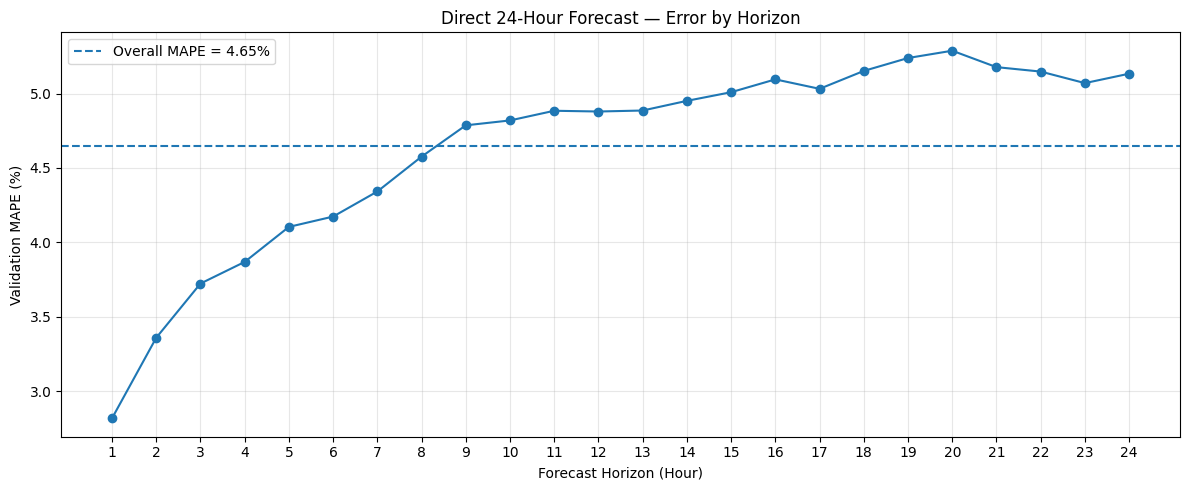

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(
    horizon_results["Forecast_Hour"],
    horizon_results["Validation_MAPE"],
    marker="o"
)

plt.axhline(
    val_mape_direct_24,
    linestyle="--",
    label=(
        f"Overall MAPE = "
        f"{val_mape_direct_24:.2f}%"
    )
)

plt.xlabel("Forecast Horizon (Hour)")
plt.ylabel("Validation MAPE (%)")

plt.title(
    "Direct 24-Hour Forecast — Error by Horizon"
)

plt.xticks(range(1, 25))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()